# Polymarket 回測 — 含 Risk Score 風險調整策略

**核心想法**：`temp_trajectory_ml.ipynb` 證明了預報曲線形狀可以預測當天最高溫的「不確定性」（`risk_score` = 80% 預測區間寬度）。這個 notebook 把 `risk_score` 接進回測，比較三種策略：

| 策略 | 邏輯 |
|---|---|
| **A. 基準** | 每天固定下注，完全不管風險高低 |
| **B. 硬過濾** | `risk_score` 超過門檻的日子直接跳過 |
| **C. 反比縮放** | 風險越高下注越少，風險越低下注越多（連續調整） |

**風險假說**：高 `risk_score` 的日子輸多贏少（或輸贏無法預期），過濾 / 縮減這些日子應該改善 Sharpe 或最終資金。

---

## ⚙️ 參數設定（只需改這裡）

In [2]:
# ── 城市選擇 ──────────────────────────────────────────────────────────────────
CITY = "ALL"           # "ALL" 或單一城市 location_key

# ── 進場設定 ──────────────────────────────────────────────────────────────────
LEAD_HOURS  = 20       # 距結算幾小時前進場（同時用於 risk_score 的預報快照）
LEAD_TOL    = 2.0      # lead time 容忍範圍（±小時）
SINCE_DATE  = "2026-03-01"

# ── 下注策略 ──────────────────────────────────────────────────────────────────
FIXED_BET       = 5.0    # 基準每筆下注（策略 A）
INITIAL_CAPITAL = 100.0

MAX_PROB_FILTER = 0.80   # 過濾過度確信場次（yes_prob > 閾值則跳過）
SETTLE_RULE     = "nearest"
PEAK_FEE_RATE   = 0.0125

# ── Risk Score 參數 ───────────────────────────────────────────────────────────
# 策略 B：risk_score 超過此值就跳過（None = 自動取 P75）
RISK_THRESHOLD  = None
# 策略 C：反比縮放的參考基準（None = 自動取中位數）
RISK_REF        = None
# 策略 C 的最大倍率（低風險日最多下注幾倍基準？）
MAX_MULT        = 2.5

## 🔧 核心程式（不需修改）

In [3]:
import os, re, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2
import psycopg2.extras
from psycopg2.extras import execute_values
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold
from dotenv import load_dotenv

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = ["Arial Unicode MS", "Heiti TC", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False
np.random.seed(42)
load_dotenv(Path("..") / ".env")

ALL_CITIES = [
    "us/ny/new-york-city/KLGA", "us/il/chicago/KORD", "gb/london/EGLC",
    "us/fl/miami/KMIA", "us/ga/atlanta/KATL", "us/tx/dallas/KDAL",
    "us/wa/seatac/KSEA", "ca/mississauga/CYYZ", "fr/paris/LFPG",
    "tr/çubuk/LTAC", "kr/incheon/RKSI", "nz/wellington/NZWN",
    "br/guarulhos/SBGR", "ar/ezeiza/SAEZ",
]
CITY_NAMES = {
    "us/ny/new-york-city/KLGA":"NYC",   "us/il/chicago/KORD":"Chicago",
    "gb/london/EGLC":"London",          "us/fl/miami/KMIA":"Miami",
    "us/ga/atlanta/KATL":"Atlanta",     "us/tx/dallas/KDAL":"Dallas",
    "us/wa/seatac/KSEA":"Seattle",      "ca/mississauga/CYYZ":"Toronto",
    "fr/paris/LFPG":"Paris",            "tr/çubuk/LTAC":"Ankara",
    "kr/incheon/RKSI":"Incheon",        "nz/wellington/NZWN":"Wellington",
    "br/guarulhos/SBGR":"SaoPaulo",     "ar/ezeiza/SAEZ":"BuenosAires",
}
CITY_LAT = {
    "us/ny/new-york-city/KLGA":40.8, "us/il/chicago/KORD":42.0,
    "gb/london/EGLC":51.5,           "us/fl/miami/KMIA":25.8,
    "us/ga/atlanta/KATL":33.7,       "us/tx/dallas/KDAL":32.8,
    "us/wa/seatac/KSEA":47.4,        "ca/mississauga/CYYZ":43.7,
    "fr/paris/LFPG":49.0,            "tr/çubuk/LTAC":40.0,
    "kr/incheon/RKSI":37.5,          "nz/wellington/NZWN":-41.3,
    "br/guarulhos/SBGR":-23.4,       "ar/ezeiza/SAEZ":-34.8,
}

_RANGE_RE = re.compile(r"(-?\d+)\s*-\s*(-?\d+)")
_BOUND_RE = re.compile(r"(-?\d+)\s*°?[CF]?\s*(or higher|or above|or below)", re.I)

def covers(label, actual, rule="nearest"):
    m = _BOUND_RE.search(label)
    if m:
        t = int(m.group(1)); tail = m.group(2).lower()
        return actual >= t if ("high" in tail or "above" in tail) else actual < t + 1
    m = _RANGE_RE.search(label)
    if m:
        lo, hi = int(m.group(1)), int(m.group(2))
        return lo <= actual < hi + 1
    m = re.search(r"(-?\d+)", label)
    if m:
        t = int(m.group(1))
        return abs(actual - t) < 0.5 if rule == "nearest" else t <= actual < t + 1
    return False

def f_to_c(f): return (f - 32) * 5 / 9

def taker_fee(prob, peak): return peak * 4 * prob * (1 - prob)

def get_conn():
    return psycopg2.connect(os.environ["DATABASE_URL"], sslmode="require",
                            keepalives=1, keepalives_idle=30,
                            keepalives_interval=10, keepalives_count=5)

def climate_zone(lat):
    a = abs(lat)
    if a < 23.5: return "tropical"
    if a < 35:   return "subtropical"
    if a < 50:   return "temperate"
    return "cool"

print("✅ 套件載入完成")

✅ 套件載入完成


In [4]:
# ── Risk Score 計算：曲線特徵工程 + 分位數回歸（5-fold OOF）────────────────────

PEAK_WINDOW  = (11, 19)
PLATEAU_TOL  = 1.0
MIN_FC_HOURS = 14
FEATS_NUM = ["fc_peak","fc_range","plateau_w","feels_gap_peak","wind_day_mean",
             "morning_min","rise_4h","fall_4h","curv_peak","prev_fc_error",
             "fc_minus_prev_actual","lat","doy_sin","doy_cos"]
FEATS_CAT = ["zone"]
ALL_FEATS = FEATS_NUM + FEATS_CAT

def curve_features(g):
    s  = g.set_index("forecast_hour")["temp_f"].reindex(range(24))
    fl = g.set_index("forecast_hour")["feels_like_f"].reindex(range(24))
    wd = g.set_index("forecast_hour")["wind_mph"].reindex(range(24))
    pw0, pw1 = PEAK_WINDOW
    day = s.loc[pw0:pw1].dropna()
    if day.empty: day = s.dropna()
    if day.empty:
        return pd.Series({k: np.nan for k in ["fc_peak","fc_range","plateau_w",
                          "feels_gap_peak","wind_day_mean","morning_min",
                          "rise_4h","fall_4h","curv_peak"]})
    peak = float(day.max()); ph = int(day.idxmax()); vis = s.dropna()
    return pd.Series({
        "fc_peak":        peak,
        "fc_range":       peak - float(vis.min()),
        "plateau_w":      int((s >= peak - PLATEAU_TOL).sum()),
        "feels_gap_peak": float(fl.get(ph, np.nan)) - peak,
        "wind_day_mean":  float(wd.loc[10:18].mean()),
        "morning_min":    float(s.loc[4:8].min()),
        "rise_4h":        peak - float(s.get(ph - 4, np.nan)),
        "fall_4h":        peak - float(s.get(ph + 4, np.nan)),
        "curv_peak":      float(s.get(ph-1,np.nan)) - 2*peak + float(s.get(ph+1,np.nan)),
    })

def compute_risk_scores(conn, cities_list, lead_hours, lead_tol, since):
    lo, hi = lead_hours - lead_tol, lead_hours + lead_tol
    cf = "AND fs.location_key = ANY(%(cities)s)" if cities_list != ALL_CITIES else ""
    base_sql = f'''
        WITH picked AS (
          SELECT DISTINCT ON (fs.location_key, fs.target_date)
                 fs.location_key, fs.target_date, fs.snapshot_time
          FROM forecast_snapshots fs
          WHERE fs.target_date >= %(since)s
            AND fs.n_forecast_hours >= %(minh)s
            AND fs.hours_before_close BETWEEN %(lo)s AND %(hi)s
            {cf}
          ORDER BY fs.location_key, fs.target_date, abs(fs.hours_before_close - %(lead)s)
        )
        SELECT p.*, c.celsius, ds.official_high_f
        FROM picked p
        JOIN cities c USING(location_key)
        LEFT JOIN weather_daily_summary ds
               ON ds.location_key=p.location_key AND ds.obs_date=p.target_date
        ORDER BY p.location_key, p.target_date
    '''
    base = pd.read_sql(base_sql, conn,
                       params={"since":since,"minh":MIN_FC_HOURS,"lo":lo,"hi":hi,
                               "lead":lead_hours,"cities":cities_list})

    cur = conn.cursor()
    cur.execute("CREATE TEMP TABLE IF NOT EXISTS _pick_rs"
                "(location_key text, target_date date, snapshot_time timestamptz)")
    cur.execute("DELETE FROM _pick_rs")
    execute_values(cur, "INSERT INTO _pick_rs VALUES %s",
                   list(base[["location_key","target_date","snapshot_time"]]
                        .drop_duplicates().itertuples(index=False, name=None)))
    conn.commit()

    curves = pd.read_sql('''
        SELECT h.location_key, h.target_date, h.forecast_hour,
               h.temp_f, h.feels_like_f, h.wind_mph
        FROM forecast_hourly_snapshots h
        JOIN _pick_rs p ON p.location_key=h.location_key
                       AND p.target_date=h.target_date
                       AND p.snapshot_time=h.snapshot_time
    ''', conn)

    feat = curves.groupby(["location_key","target_date"]).apply(curve_features).reset_index()
    df   = base.merge(feat, on=["location_key","target_date"], how="inner")
    df   = df.sort_values(["location_key","target_date"]).reset_index(drop=True)

    gg = df.groupby("location_key")
    df["prev_fc_peak"]         = gg["fc_peak"].shift(1)
    df["prev_actual_high"]     = gg["official_high_f"].shift(1)
    df["prev_fc_error"]        = df["prev_actual_high"] - df["prev_fc_peak"]
    df["fc_minus_prev_actual"] = df["fc_peak"] - df["prev_actual_high"]
    df["lat"]     = df["location_key"].map(CITY_LAT)
    df["zone"]    = df["lat"].map(climate_zone)
    dt = pd.to_datetime(df["target_date"])
    df["doy_sin"] = np.sin(2*np.pi*dt.dt.dayofyear/365.25)
    df["doy_cos"] = np.cos(2*np.pi*dt.dt.dayofyear/365.25)
    df = df.dropna(subset=["official_high_f","fc_peak"]).reset_index(drop=True)

    dfm = df.copy()
    for c in FEATS_NUM:
        dfm[c] = dfm[c].fillna(dfm[c].median())
    X = dfm[ALL_FEATS]; y = dfm["official_high_f"].values
    groups = dfm["target_date"].astype(str).values

    def _pipe(alpha):
        pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), FEATS_CAT)],
                                remainder="passthrough")
        return Pipeline([("pre",pre),
                         ("gbr", GradientBoostingRegressor(loss="quantile", alpha=alpha,
                                  n_estimators=150, max_depth=2, learning_rate=0.05,
                                  subsample=0.8, min_samples_leaf=15, random_state=42))])

    gkf = GroupKFold(n_splits=5)
    q10 = np.zeros(len(dfm)); q90 = np.zeros(len(dfm))
    for tr, te in gkf.split(X, y, groups):
        q10[te] = _pipe(0.10).fit(X.iloc[tr], y[tr]).predict(X.iloc[te])
        q90[te] = _pipe(0.90).fit(X.iloc[tr], y[tr]).predict(X.iloc[te])
    q90 = np.maximum(q90, q10)

    dfm["risk_score"] = q90 - q10
    out = dfm[["location_key","target_date","risk_score","fc_peak","plateau_w"]].copy()
    out["target_date"] = pd.to_datetime(out["target_date"]).dt.date
    print(f"risk_score 計算完成：{len(out)} 城市天")
    print(f"  mean={out.risk_score.mean():.2f}°F  "
          f"P25={out.risk_score.quantile(.25):.1f}  P50={out.risk_score.quantile(.5):.1f}  "
          f"P75={out.risk_score.quantile(.75):.1f}  max={out.risk_score.max():.1f}")
    return out

print("✅ risk_score 函式定義完成")

✅ risk_score 函式定義完成


In [5]:
# ── 回測函式（含 risk_score 策略邏輯）─────────────────────────────────────────

def load_city_data(conn, loc, lead_hours, lead_tol, since):
    lo, hi = lead_hours - lead_tol, lead_hours + lead_tol
    sql = '''
    WITH snaps AS (
      SELECT DISTINCT ON (market_date)
             market_date, snapshot_time
      FROM market_snapshots
      WHERE location_key = %s AND hours_before_close BETWEEN %s AND %s
        AND market_date >= %s
      ORDER BY market_date, ABS(hours_before_close - %s) ASC
    )
    SELECT s.market_date, ms.option_label, ms.yes_prob,
           wds.official_high_f, c.celsius
    FROM snaps s
    JOIN market_snapshots ms
      ON ms.location_key = %s AND ms.market_date = s.market_date
     AND ms.snapshot_time = s.snapshot_time
    JOIN weather_daily_summary wds
      ON wds.location_key = %s AND wds.obs_date = s.market_date
    JOIN cities c ON c.location_key = %s
    WHERE wds.official_high_f IS NOT NULL AND ms.yes_prob IS NOT NULL
    ORDER BY s.market_date, ms.yes_prob DESC
    '''
    with conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor) as cur:
        cur.execute(sql, (loc, lo, hi, since, lead_hours, loc, loc, loc))
        rows = cur.fetchall()
    days = defaultdict(list)
    for r in rows:
        days[r["market_date"]].append({
            "label":  r["option_label"],
            "p":      float(r["yes_prob"]),
            "high_f": float(r["official_high_f"]),
            "celsius":r["celsius"],
        })
    return [{"date": d, "opts": v} for d, v in sorted(days.items())]


def run_backtest(data, risk_idx, strategy,
                 fixed_bet, risk_threshold, risk_ref, max_mult,
                 initial, settle_rule, max_prob, peak_fee):
    '''
    strategy:
      "A" = flat fixed_bet
      "B" = skip if risk_score > risk_threshold
      "C" = bet = fixed_bet * (risk_ref / max(risk_score, 1)), capped at max_mult
    risk_idx: pd.Series indexed by date -> risk_score
    '''
    capital = initial
    records = []
    for day in data:
        opts = sorted(day["opts"], key=lambda o: -o["p"])
        top  = opts[0]
        if top["p"] > max_prob:
            continue
        d  = day["date"]
        rs = float(risk_idx.get(d, np.nan))

        if strategy == "A":
            bet_size = fixed_bet
        elif strategy == "B":
            if np.isnan(rs) or rs > risk_threshold:
                continue
            bet_size = fixed_bet
        else:  # "C"
            mult     = min(risk_ref / max(rs if not np.isnan(rs) else risk_ref, 1.0), max_mult)
            bet_size = fixed_bet * mult

        actual    = f_to_c(top["high_f"]) if top["celsius"] else top["high_f"]
        won       = covers(top["label"], actual, settle_rule)
        fee_rate  = taker_fee(top["p"], peak_fee)
        fee_amt   = bet_size * fee_rate
        gross     = bet_size * (1 / top["p"] - 1) if won else -bet_size
        net       = gross - fee_amt
        capital  += net
        records.append({"date":d, "label":top["label"], "prob":top["p"],
                         "actual":actual, "won":won, "bet":bet_size,
                         "risk_score":rs, "fee_amt":fee_amt,
                         "gross_pnl":gross, "net_pnl":net, "capital":capital})
    return pd.DataFrame(records)

print("✅ 回測函式定義完成")

✅ 回測函式定義完成


In [6]:
# ── 執行三種策略 ──────────────────────────────────────────────────────────────
conn    = get_conn()
cities  = ALL_CITIES if CITY == "ALL" else [CITY]

print("⏳ 計算 risk_score（約 1–2 分鐘）…")
risk_df = compute_risk_scores(conn, ALL_CITIES if CITY == "ALL" else cities,
                              LEAD_HOURS, LEAD_TOL, SINCE_DATE)

risk_threshold = RISK_THRESHOLD if RISK_THRESHOLD is not None else float(risk_df.risk_score.quantile(0.75))
risk_ref       = RISK_REF       if RISK_REF       is not None else float(risk_df.risk_score.median())
print(f"\n硬過濾門檻  = {risk_threshold:.1f}°F（> 此值就跳過，約 25% 高風險天）")
print(f"反比縮放基準 = {risk_ref:.1f}°F（低風險日最多 ×{MAX_MULT} 倍下注）\n")

ST_LABELS = {
    "A": "A. 基準（固定下注）",
    "B": f"B. 硬過濾（risk ≤ {risk_threshold:.0f}°F）",
    "C": f"C. 反比縮放（基準 {risk_ref:.0f}°F / risk，上限 ×{MAX_MULT}）",
}

results = {s: {} for s in "ABC"}
for loc in cities:
    data = load_city_data(conn, loc, LEAD_HOURS, LEAD_TOL, SINCE_DATE)
    if not data:
        print(f"  ⚠️  {CITY_NAMES.get(loc,loc)}：無市場資料")
        continue
    risk_idx = risk_df[risk_df.location_key == loc].set_index("target_date")["risk_score"]
    for st in "ABC":
        results[st][loc] = run_backtest(
            data, risk_idx, st, FIXED_BET, risk_threshold, risk_ref, MAX_MULT,
            INITIAL_CAPITAL, SETTLE_RULE, MAX_PROB_FILTER, PEAK_FEE_RATE)

conn.close()

# 彙總
print(f"\n{'策略':<38}  {'交易':>5}  {'勝率':>6}  {'淨ROI':>8}  {'平均最終資金':>10}")
print("-"*75)
for st in "ABC":
    all_r = pd.concat(results[st].values()) if results[st] else pd.DataFrame()
    if all_r.empty: continue
    n   = len(all_r); wr = all_r.won.mean()
    roi = all_r.net_pnl.sum() / all_r.bet.sum() * 100
    finals = [df.capital.iloc[-1] for df in results[st].values() if len(df)]
    print(f"  {ST_LABELS[st]:<36}  {n:>5}  {wr:>5.1%}  {roi:>+7.1f}%  {np.mean(finals):>9.2f}")

⏳ 計算 risk_score（約 1–2 分鐘）…
risk_score 計算完成：1010 城市天
  mean=6.83°F  P25=4.5  P50=5.9  P75=7.7  max=32.1

硬過濾門檻  = 7.7°F（> 此值就跳過，約 25% 高風險天）
反比縮放基準 = 5.9°F（低風險日最多 ×2.5 倍下注）


策略                                         交易      勝率      淨ROI      平均最終資金
---------------------------------------------------------------------------
  A. 基準（固定下注）                             870  45.6%     +2.0%     106.15
  B. 硬過濾（risk ≤ 8°F）                      667  46.2%     +3.4%     108.12
  C. 反比縮放（基準 6°F / risk，上限 ×2.5）          870  45.6%     +6.2%     120.97


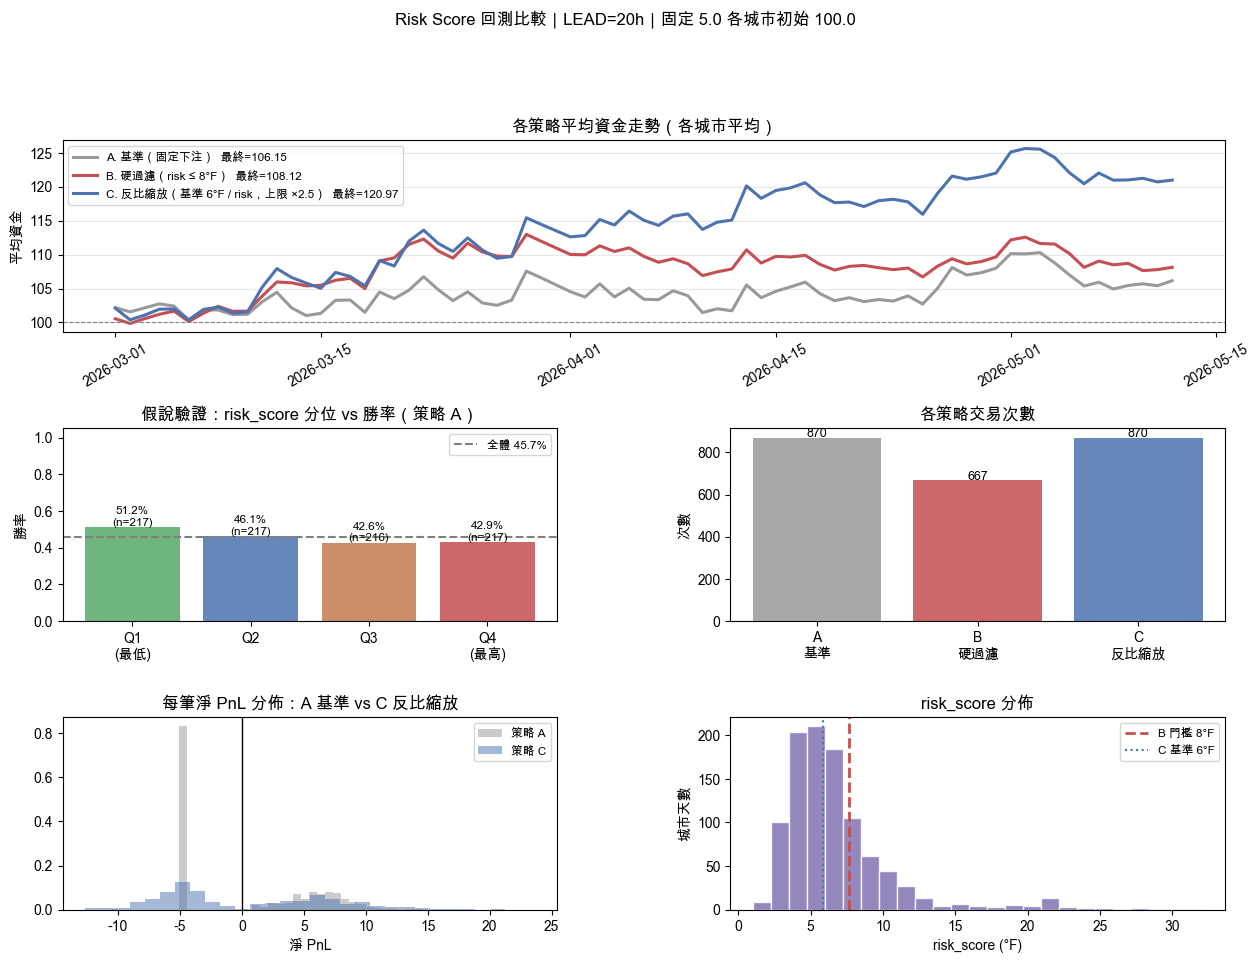

In [7]:
# ── 圖表 ─────────────────────────────────────────────────────────────────────
ST_COLORS = {"A":"#999999", "B":"#C44E52", "C":"#4C72B0"}
fig = plt.figure(figsize=(15, 10))
gs  = fig.add_gridspec(3, 2, hspace=0.50, wspace=0.35)
ax_cap  = fig.add_subplot(gs[0, :])
ax_wr   = fig.add_subplot(gs[1, 0])
ax_cnt  = fig.add_subplot(gs[1, 1])
ax_pnl  = fig.add_subplot(gs[2, 0])
ax_risk = fig.add_subplot(gs[2, 1])

# (1) 平均資金曲線（各城市平均）
for st in "ABC":
    sr = results[st]
    if not sr: continue
    dfs = [df.set_index("date")["capital"] for df in sr.values() if len(df)]
    idx = sorted(set().union(*[set(s.index) for s in dfs]))
    avg = pd.DataFrame({i: s.reindex(idx).ffill().bfill() for i,s in enumerate(dfs)}).mean(axis=1)
    ax_cap.plot(pd.to_datetime(idx), avg, color=ST_COLORS[st], lw=2.2,
                label=f"{ST_LABELS[st]}  最終={avg.iloc[-1]:.2f}")
ax_cap.axhline(INITIAL_CAPITAL, color="gray", lw=0.8, ls="--")
ax_cap.set_title("各策略平均資金走勢（各城市平均）", fontweight="bold")
ax_cap.set_ylabel("平均資金"); ax_cap.legend(fontsize=8.5)
ax_cap.grid(axis="y", alpha=0.3); ax_cap.tick_params(axis="x", rotation=30)

# (2) 勝率 vs risk_score 分位（策略 A，驗證假說）
all_a = pd.concat(results["A"].values()) if results["A"] else pd.DataFrame()
if not all_a.empty and all_a.risk_score.notna().any():
    all_a2 = all_a.dropna(subset=["risk_score"])
    all_a2 = all_a2.assign(
        risk_q=pd.qcut(all_a2.risk_score, q=4, labels=["Q1\n(最低)","Q2","Q3","Q4\n(最高)"]))
    wr_q = all_a2.groupby("risk_q", observed=True)["won"].mean()
    n_q  = all_a2.groupby("risk_q", observed=True).size()
    bar_colors = ["#55A868","#4C72B0","#C47A4E","#C44E52"]
    ax_wr.bar(range(len(wr_q)), wr_q.values, color=bar_colors, alpha=0.85)
    ax_wr.axhline(all_a2.won.mean(), color="gray", ls="--",
                  label=f"全體 {all_a2.won.mean():.1%}")
    ax_wr.set_xticks(range(len(wr_q))); ax_wr.set_xticklabels(wr_q.index)
    for i, (wr, n) in enumerate(zip(wr_q.values, n_q.values)):
        ax_wr.text(i, wr+0.01, f"{wr:.1%}\n(n={n})", ha="center", fontsize=8.5)
    ax_wr.set_title("假說驗證：risk_score 分位 vs 勝率（策略 A）", fontweight="bold")
    ax_wr.set_ylabel("勝率"); ax_wr.set_ylim(0, 1.05); ax_wr.legend(fontsize=8.5)

# (3) 各策略交易次數
trade_cnt = [sum(len(df) for df in results[s].values()) for s in "ABC"]
bars = ax_cnt.bar(range(3), trade_cnt, color=[ST_COLORS[s] for s in "ABC"], alpha=0.85)
ax_cnt.set_xticks(range(3)); ax_cnt.set_xticklabels(["A\n基準","B\n硬過濾","C\n反比縮放"])
ax_cnt.set_title("各策略交易次數", fontweight="bold"); ax_cnt.set_ylabel("次數")
for bar, n in zip(bars, trade_cnt):
    ax_cnt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, str(n),
                ha="center", fontsize=9)

# (4) 淨PnL分佈：A vs C
for st, col in [("A","#999999"),("C","#4C72B0")]:
    r = results.get(st,{})
    if r:
        pnl = pd.concat(r.values())["net_pnl"]
        ax_pnl.hist(pnl, bins=30, alpha=0.5, color=col, label=f"策略 {st}", density=True)
ax_pnl.axvline(0, color="black", lw=1)
ax_pnl.set_title("每筆淨 PnL 分佈：A 基準 vs C 反比縮放", fontweight="bold")
ax_pnl.set_xlabel("淨 PnL"); ax_pnl.legend(fontsize=8.5)

# (5) risk_score 分佈 + 門檻線
ax_risk.hist(risk_df.risk_score, bins=25, color="#8172B2", edgecolor="white", alpha=0.85)
ax_risk.axvline(risk_threshold, color="#C44E52", lw=2, ls="--",
                label=f"B 門檻 {risk_threshold:.0f}°F")
ax_risk.axvline(risk_ref, color="#4C72B0", lw=1.5, ls=":",
                label=f"C 基準 {risk_ref:.0f}°F")
ax_risk.set_title("risk_score 分佈", fontweight="bold")
ax_risk.set_xlabel("risk_score (°F)"); ax_risk.set_ylabel("城市天數"); ax_risk.legend(fontsize=8.5)

plt.suptitle(
    f"Risk Score 回測比較｜LEAD={LEAD_HOURS}h｜固定 {FIXED_BET} 各城市初始 {INITIAL_CAPITAL}",
    fontweight="bold", fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

In [8]:
# ── 詳細績效指標 ──────────────────────────────────────────────────────────────
def calc_metrics(st_results, initial):
    if not st_results: return {}
    all_df = pd.concat(st_results.values())
    if all_df.empty: return {}
    n   = len(all_df); wr = all_df.won.mean()
    roi = all_df.net_pnl.sum() / all_df.bet.sum() * 100
    mdds = []
    for df in st_results.values():
        if df.empty: continue
        cap = np.array([initial] + list(df.capital))
        peak = np.maximum.accumulate(cap)
        mdds.append((peak - cap).max())
    sharpes = []
    for df in st_results.values():
        if len(df) < 3: continue
        p = df.net_pnl
        if p.std() > 0:
            sharpes.append(p.mean() / p.std() * np.sqrt(len(p)))
    return {
        "交易數": n, "勝率": f"{wr:.1%}", "淨ROI": f"{roi:+.2f}%",
        "平均MDD": f"{np.mean(mdds):.2f}", "Sharpe-like": f"{np.mean(sharpes):.3f}" if sharpes else "—"
    }

rows = []
for st in "ABC":
    m = calc_metrics(results.get(st,{}), INITIAL_CAPITAL)
    if m: rows.append({"策略": ST_LABELS[st], **m})
print("=== 績效指標（out-of-fold risk_score）===")
print(pd.DataFrame(rows).set_index("策略").to_string())

# ── 風險分層：高風險天 vs 低風險天的勝率 / 期望值（策略 A）──────────────────────
all_a = pd.concat(results["A"].values()).dropna(subset=["risk_score"]) if results["A"] else pd.DataFrame()
if not all_a.empty:
    q25, q50, q75 = (risk_df.risk_score.quantile(q) for q in [.25,.5,.75])
    all_a["tier"] = pd.cut(all_a.risk_score, bins=[0,q25,q50,q75,999],
                           labels=["Q1 低風險","Q2","Q3","Q4 高風險"])
    print("\n=== 策略 A：依 risk_score 分層績效 ===")
    print(all_a.groupby("tier", observed=True).agg(
        n=("won","count"), win_rate=("won","mean"),
        avg_net_pnl=("net_pnl","mean"), std_pnl=("net_pnl","std")
    ).round(3).to_string())

=== 績效指標（out-of-fold risk_score）===
                                交易數     勝率    淨ROI  平均MDD Sharpe-like
策略                                                                   
A. 基準（固定下注）                     870  45.6%  +1.98%  54.08       0.113
B. 硬過濾（risk ≤ 8°F）              667  46.2%  +3.41%  43.36       0.135
C. 反比縮放（基準 6°F / risk，上限 ×2.5）  870  45.6%  +6.23%  51.08       0.336

=== 策略 A：依 risk_score 分層績效 ===
          n  win_rate  avg_net_pnl  std_pnl
tier                                       
Q1 低風險  226     0.509        0.659    5.893
Q2      220     0.473        0.330    5.863
Q3      221     0.403       -0.488    5.811
Q4 高風險  200     0.440       -0.130    5.843


## 🎲 Bootstrap Monte Carlo

對三種策略的實際交易記錄做有放回重採樣，估計績效的不確定性範圍。

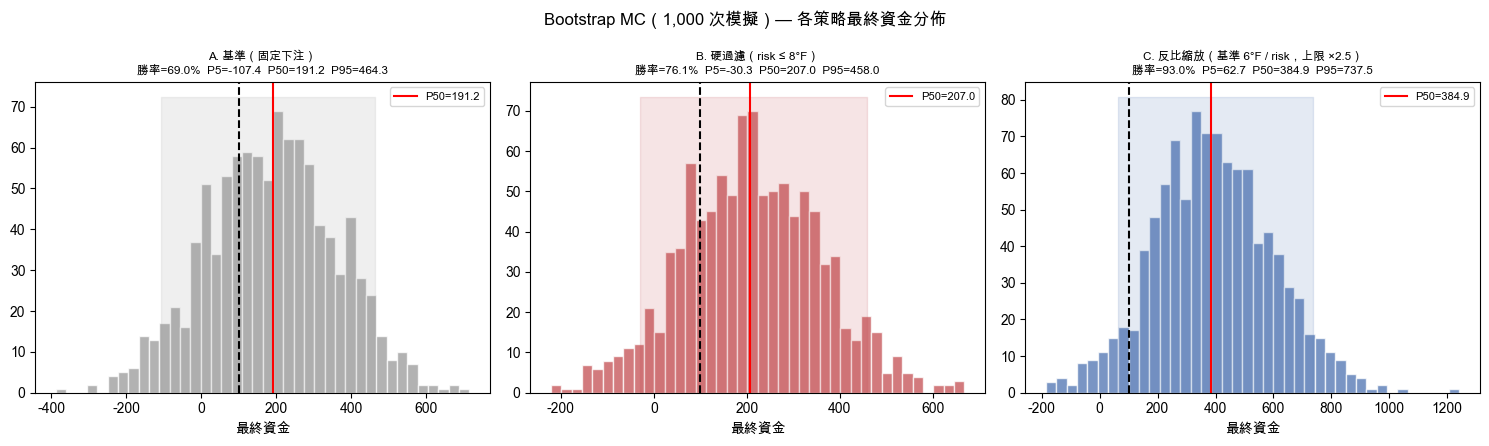

                                  n     P5    P50    P95  P(獲利)
策略                                                             
A. 基準（固定下注）                     870 -107.4  191.2  464.3  69.0%
B. 硬過濾（risk ≤ 8°F）              667  -30.3  207.0  458.0  76.1%
C. 反比縮放（基準 6°F / risk，上限 ×2.5）  870   62.7  384.9  737.5  93.0%


In [9]:
N_SIMULATIONS = 1_000
rng = np.random.default_rng(42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
mc_rows = []

for ax, st in zip(axes, "ABC"):
    sr = results.get(st, {})
    if not sr: continue
    pnl = pd.concat(sr.values())["net_pnl"].values
    if len(pnl) == 0: continue

    finals = INITIAL_CAPITAL + np.array([
        rng.choice(pnl, size=len(pnl), replace=True).sum()
        for _ in range(N_SIMULATIONS)
    ])
    p5, p50, p95 = np.percentile(finals, [5, 50, 95])
    win_p = (finals > INITIAL_CAPITAL).mean()

    ax.hist(finals, bins=40, color=ST_COLORS[st], alpha=0.75, edgecolor="white")
    ax.axvline(INITIAL_CAPITAL, color="black", lw=1.5, ls="--")
    ax.axvline(p50, color="red", lw=1.5, label=f"P50={p50:.1f}")
    ymax = ax.get_ylim()[1]
    ax.fill_betweenx([0, ymax if ymax > 0 else 200],
                     p5, p95, alpha=0.15, color=ST_COLORS[st])
    ax.set_title(
        f"{ST_LABELS[st]}\n勝率={win_p:.1%}  P5={p5:.1f}  P50={p50:.1f}  P95={p95:.1f}",
        fontsize=8.5, fontweight="bold")
    ax.set_xlabel("最終資金"); ax.legend(fontsize=8)
    mc_rows.append({"策略":ST_LABELS[st],"n":len(pnl),
                    "P5":round(p5,1),"P50":round(p50,1),"P95":round(p95,1),
                    "P(獲利)":f"{win_p:.1%}"})

plt.suptitle(f"Bootstrap MC（{N_SIMULATIONS:,} 次模擬）— 各策略最終資金分佈",
             fontweight="bold")
plt.tight_layout(); plt.show()
print(pd.DataFrame(mc_rows).set_index("策略").to_string())